# 🏦 Loan Approval Prediction


In [ ]:
# All these are pre-installed on Google Colab — no pip needed!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   Pandas version     : {pd.__version__}')

✅ All libraries imported successfully!
   TensorFlow version : 2.20.0
   Pandas version     : 2.2.2


## Create Dataset

In [ ]:
# ── Dataset is fully embedded — no CSV file upload needed! ──
data = {
    'Salary': [
        75000, 45000, 30000, 90000, 25000, 60000, 38000, 85000, 20000, 55000,
        40000, 95000, 28000, 70000, 35000, 80000, 22000, 65000, 42000, 50000,
        18000, 88000, 33000, 72000, 26000, 58000, 44000, 92000, 23000, 67000,
        37000, 82000, 21000, 62000, 39000, 77000, 24000, 52000, 46000, 98000,
        17000, 86000, 31000, 68000, 27000, 57000, 43000, 91000, 19000, 74000
    ],
    'Age': [
        35, 28, 22, 42, 19, 31, 26, 45, 21, 33, 29, 50, 24, 37, 27, 40, 20,
        34, 30, 32, 19, 48, 25, 36, 23, 31, 29, 52, 21, 38, 27, 43, 20, 35,
        28, 39, 22, 33, 30, 55, 18, 47, 25, 36, 23, 32, 29, 51, 20, 37
    ],
    'CreditScore': [
        720, 650, 580, 780, 520, 700, 610, 760, 500, 690, 630, 800, 560, 730,
        600, 755, 510, 715, 640, 675, 490, 775, 590, 735, 545, 695, 655, 790,
        530, 720, 615, 760, 505, 705, 625, 745, 540, 680, 660, 810, 480, 770,
        575, 725, 550, 692, 648, 785, 495, 738
    ],
    'EmploymentStatus': [
        1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 1, 1, 0, 1
    ],
    'LoanAmount': [
        200000, 150000, 100000, 300000,  80000, 180000, 120000, 250000,  60000, 170000,
        130000, 350000,  90000, 220000, 110000, 270000,  70000, 195000, 140000, 160000,
         50000, 320000, 105000, 210000,  85000, 175000, 145000, 340000,  75000, 200000,
        115000, 280000,  65000, 185000, 125000, 235000,  78000, 163000, 148000, 380000,
         45000, 310000,  98000, 205000,  88000, 172000, 142000, 335000,  55000, 225000
    ],
    'Approved': [
        1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

print(f'✅ Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Approved : {df["Approved"].sum()}  |  Rejected : {(df["Approved"]==0).sum()}')
df.head(10)

✅ Dataset ready: 50 rows × 6 columns
   Approved : 29  |  Rejected : 21


,Salary,Age,CreditScore,EmploymentStatus,LoanAmount,Approved
0,75000,35,720,1,200000,1
1,45000,28,650,1,150000,1
2,30000,22,580,0,100000,0
3,90000,42,780,1,300000,1
4,25000,19,520,0,80000,0
5,60000,31,700,1,180000,1
6,38000,26,610,1,120000,0
7,85000,45,760,1,250000,1
8,20000,21,500,0,60000,0
9,55000,33,690,1,170000,1


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/14YYy13dDV4N6UaYm3Zucouqy94BHlQtcx7mlMVvhnso/edit#gid=0


## Explore & Visualize Data

In [ ]:
print('📋 Dataset Statistics:')
df.describe().round(2)

📋 Dataset Statistics:


,Salary,Age,CreditScore,EmploymentStatus,LoanAmount,Approved
count,50.00,50.00,50.00,50.00,50.00,50.00
mean,52440.00,31.94,655.06,0.70,169980.00,0.58
std,24834.28,9.72,97.33,0.46,89007.34,0.50
min,17000.00,18.00,480.00,0.00,45000.00,0.00
25%,30250.00,24.25,576.25,0.00,98500.00,0.00
50%,48000.00,30.50,667.50,1.00,155000.00,1.00
75%,73500.00,37.00,733.75,1.00,217500.00,1.00
max,98000.00,55.00,810.00,1.00,380000.00,1.00


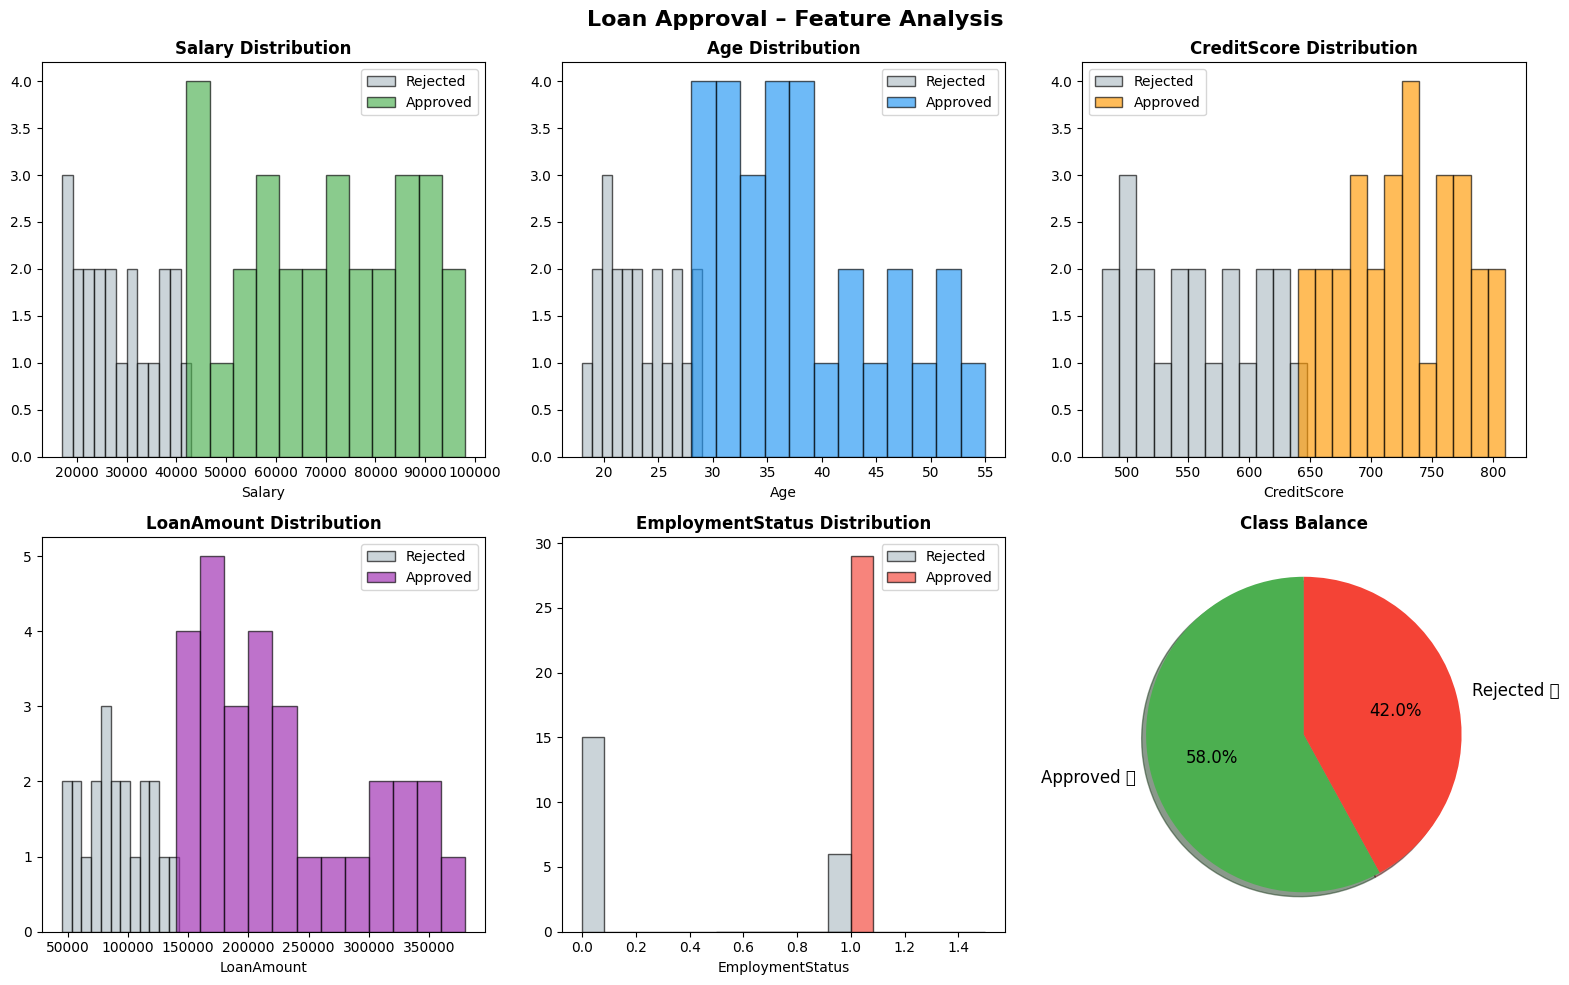

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Loan Approval – Feature Analysis', fontsize=16, fontweight='bold')

features = ['Salary', 'Age', 'CreditScore', 'LoanAmount', 'EmploymentStatus']
palette  = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

for i, (feat, col) in enumerate(zip(features, palette)):
    ax = axes[i // 3][i % 3]
    for label, grp in df.groupby('Approved'):
        ax.hist(grp[feat], bins=12, alpha=0.65,
                label='Approved' if label == 1 else 'Rejected',
                color=col if label == 1 else '#B0BEC5', edgecolor='black')
    ax.set_title(f'{feat} Distribution', fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend()

ax_pie = axes[1][2]
counts = df['Approved'].value_counts()
ax_pie.pie(
    counts,
    labels=['Approved ✅', 'Rejected ❌'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.1f%%', startangle=90, shadow=True,
    textprops={'fontsize': 12}
)
ax_pie.set_title('Class Balance', fontweight='bold')

plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
FEATURES = ['Salary', 'Age', 'CreditScore', 'EmploymentStatus', 'LoanAmount']
TARGET   = 'Approved'

X = df[FEATURES]
y = df[TARGET]

# 80% Train / 20% Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler for ANN (RF uses raw values)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Train : {len(X_train)} samples')
print(f'✅ Test  : {len(X_test)}  samples')

✅ Train : 40 samples
✅ Test  : 10  samples


---
## Train Random Forest (ML)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

rf_test_prob = rf.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_prob >= 0.5).astype(int)
rf_acc       = accuracy_score(y_test, rf_test_pred)

print(f'✅ Random Forest trained!   Accuracy on test set: {rf_acc * 100:.2f}%')

✅ Random Forest trained!   Accuracy on test set: 90.00%


##  Train ANN (Deep Learning)

In [ ]:
tf.random.set_seed(42)

ann = keras.Sequential([
    layers.Input(shape=(5,)),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # Binary output
], name='LoanANN')

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann.summary()

Model: "LoanANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = ann.fit(
    X_train_sc, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

ann_test_prob = ann.predict(X_test_sc, verbose=0).flatten()
ann_test_pred = (ann_test_prob >= 0.5).astype(int)
ann_acc       = accuracy_score(y_test, ann_test_pred)

print(f'\n✅ ANN trained!   Accuracy on test set: {ann_acc * 100:.2f}%')

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.3438 - loss: 0.9114 - val_accuracy: 0.6250 - val_loss: 0.6248
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4375 - loss: 0.7872 - val_accuracy: 0.6250 - val_loss: 0.6160
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.7331 - val_accuracy: 0.7500 - val_loss: 0.6056
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7188 - loss: 0.6638 - val_accuracy: 0.7500 - val_loss: 0.5963
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5938 - loss: 0.6061 - val_accuracy: 0.7500 - val_loss: 0.5879
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7188 - loss: 0.6778 - val_accuracy: 0.7500 - val_loss: 0.5762
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7500 - loss: 0.5854 - val_accuracy: 0.7500 - val_loss: 0.5644
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8125 - loss: 0.4891 - val_accuracy: 0.7500 - val_loss

---
##  Combine Both Models
RF and ANN probability scores are **averaged (50% + 50%)**

In [ ]:
RF_WEIGHT  = 0.5
ANN_WEIGHT = 0.5

ensemble_prob = (RF_WEIGHT * rf_test_prob) + (ANN_WEIGHT * ann_test_prob)
ensemble_pred = (ensemble_prob >= 0.5).astype(int)
ens_acc       = accuracy_score(y_test, ensemble_pred)

print('=' * 55)
print('   ENSEMBLE RESULTS  (Random Forest + ANN)')
print('=' * 55)
print(f'  Combined Accuracy : {ens_acc * 100:.2f}%')
print()
print(classification_report(
    y_test, ensemble_pred,
    target_names=['Rejected ❌', 'Approved ✅']
))

   ENSEMBLE RESULTS  (Random Forest + ANN)
  Combined Accuracy : 90.00%

              precision    recall  f1-score   support

  Rejected ❌       1.00      0.75      0.86         4
  Approved ✅       0.86      1.00      0.92         6

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



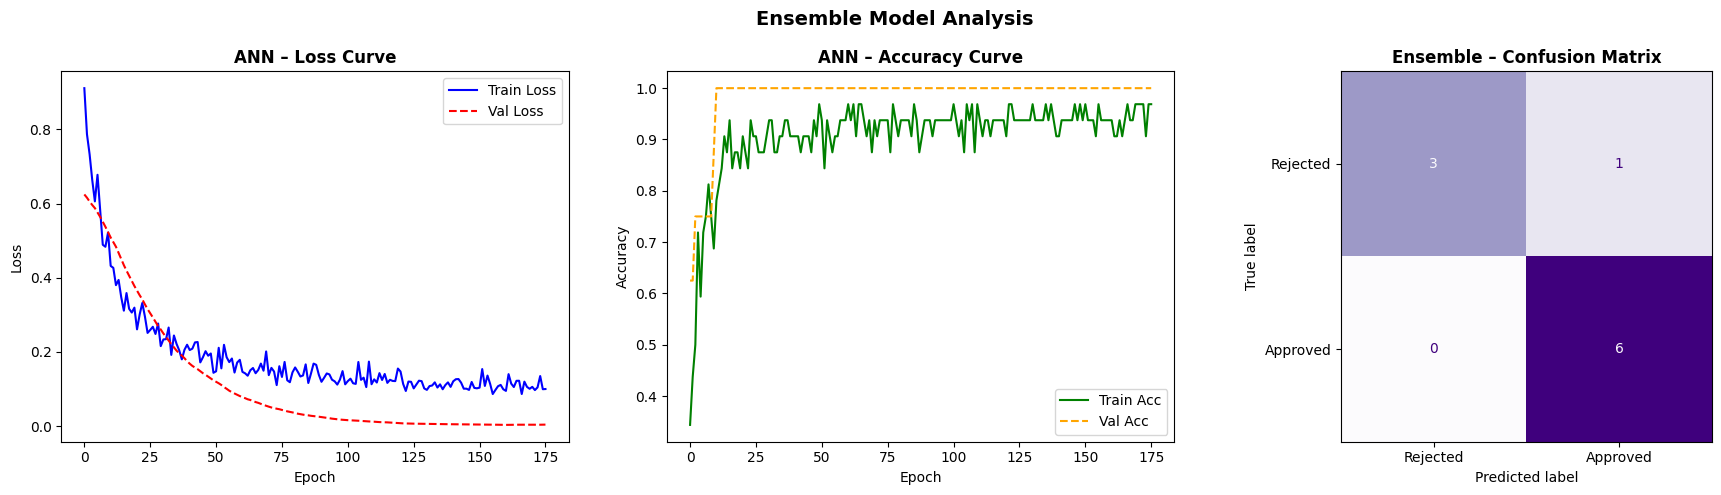

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ensemble Model Analysis', fontsize=14, fontweight='bold')

# ANN Loss Curve
axes[0].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='red', linestyle='--')
axes[0].set_title('ANN – Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ANN Accuracy Curve
axes[1].plot(history.history['accuracy'],     label='Train Acc', color='green')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='orange', linestyle='--')
axes[1].set_title('ANN – Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Ensemble Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, ensemble_pred),
    display_labels=['Rejected', 'Approved']
).plot(ax=axes[2], colorbar=False, cmap='Purples')
axes[2].set_title('Ensemble – Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

---
##  Enter YOUR Details & Get Prediction



In [ ]:
print('=' * 55)
print('       LOAN APPROVAL PREDICTION SYSTEM')
print('       Powered by RF + ANN Ensemble')
print('=' * 55)
print('Please enter your details below:\n')

salary     = float(input('💰 Annual Salary          (e.g. 60000)  : '))
age        = float(input('🎂 Age                    (e.g. 30)     : '))
cscore     = float(input('📊 Credit Score  (300-850, e.g. 700)    : '))
emp_status = int(input  ('💼 Employment    (1=Employed, 0=Not)    : '))
loan_amt   = float(input('🏠 Loan Amount            (e.g. 200000) : '))

user_df = pd.DataFrame([{
    'Salary'          : salary,
    'Age'             : age,
    'CreditScore'     : cscore,
    'EmploymentStatus': emp_status,
    'LoanAmount'      : loan_amt
}])

print('\n📋 Your Input Summary:')
print(user_df.to_string(index=False))

       LOAN APPROVAL PREDICTION SYSTEM
       Powered by RF + ANN Ensemble
Please enter your details below:

💰 Annual Salary          (e.g. 60000)  : 100000
🎂 Age                    (e.g. 30)     : 25
📊 Credit Score  (300-850, e.g. 700)    : 400
💼 Employment    (1=Employed, 0=Not)    : 1
🏠 Loan Amount            (e.g. 200000) : 20000

📋 Your Input Summary:
  Salary  Age  CreditScore  EmploymentStatus  LoanAmount
100000.0 25.0        400.0                 1     20000.0


In [ ]:
# ── Random Forest probability ──────────────────────────────
rf_user_prob  = rf.predict_proba(user_df)[0][1]

# ── ANN probability ────────────────────────────────────────
user_sc       = scaler.transform(user_df)
ann_user_prob = float(ann.predict(user_sc, verbose=0)[0][0])

# ── Ensemble: weighted average ─────────────────────────────
final_prob = (RF_WEIGHT * rf_user_prob) + (ANN_WEIGHT * ann_user_prob)
final_pred = 1 if final_prob >= 0.5 else 0
confidence = final_prob * 100 if final_pred == 1 else (1 - final_prob) * 100

status = 'APPROVED ✅' if final_pred == 1 else 'REJECTED ❌'

# ── Print result ───────────────────────────────────────────
print('\n' + '=' * 55)
print('              FINAL PREDICTION')
print('=' * 55)
print(f'  🌲 Random Forest Score  : {rf_user_prob  * 100:.1f}%')
print(f'  🧠 ANN Score            : {ann_user_prob * 100:.1f}%')
print('─' * 55)
print(f'  📊 Combined Score       : {final_prob    * 100:.1f}%')
print(f'  🏦 LOAN DECISION        : {status}')
print(f'  📈 Confidence           : {confidence:.1f}%')
print('=' * 55)


              FINAL PREDICTION
  🌲 Random Forest Score  : 31.0%
  🧠 ANN Score            : 21.1%
───────────────────────────────────────────────────────
  📊 Combined Score       : 26.0%
  🏦 LOAN DECISION        : REJECTED ❌
  📈 Confidence           : 74.0%


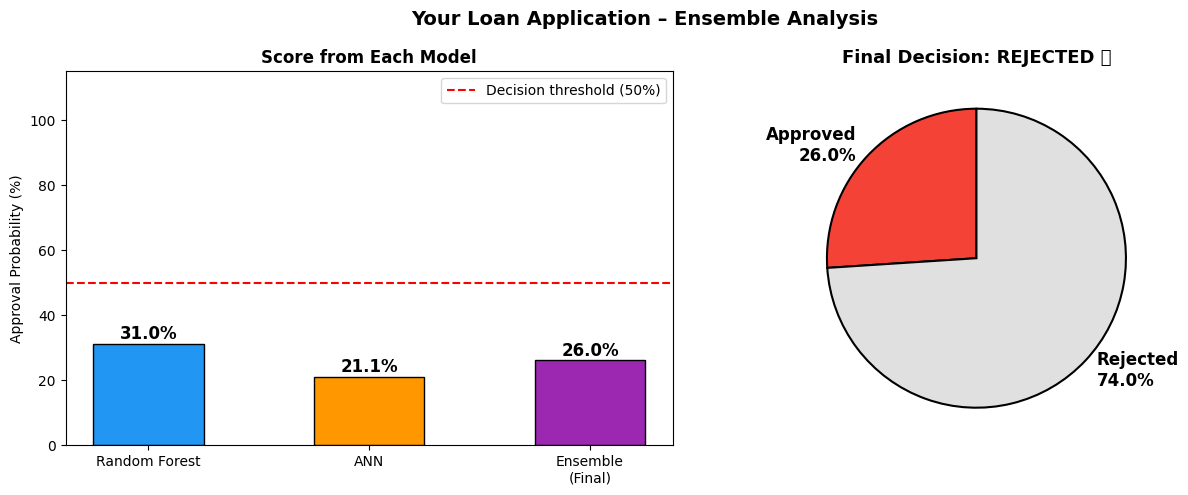

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Your Loan Application – Ensemble Analysis', fontsize=14, fontweight='bold')

# ── Bar chart: probability from each model ─────────────────
model_names = ['Random Forest', 'ANN', 'Ensemble\n(Final)']
probs       = [rf_user_prob * 100, ann_user_prob * 100, final_prob * 100]
bar_colors  = ['#2196F3', '#FF9800', '#9C27B0']

bars = axes[0].bar(model_names, probs, color=bar_colors, edgecolor='black', width=0.5)
axes[0].axhline(50, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (50%)')
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Approval Probability (%)')
axes[0].set_title('Score from Each Model', fontweight='bold')
axes[0].legend()
for b, p in zip(bars, probs):
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 1.5,
        f'{p:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

# ── Pie chart: final decision ───────────────────────────────
slice_colors = ['#4CAF50' if final_pred == 1 else '#F44336', '#E0E0E0']
axes[1].pie(
    [final_prob * 100, (1 - final_prob) * 100],
    labels=[
        f'Approved\n{final_prob*100:.1f}%',
        f'Rejected\n{(1-final_prob)*100:.1f}%'
    ],
    colors=slice_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title(f'Final Decision: {status}', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

## WHAT CREDIT SCORE DO I NEED TO GET APPROVED?

In [ ]:


print("Enter your details (Credit Score will be tested automatically)\n")

cs_salary     = float(input("💰 Annual Salary          (e.g. 60000)  : "))
cs_age        = float(input("🎂 Age                    (e.g. 30)     : "))
cs_emp_status = int(input  ("💼 Employment    (1=Employed, 0=Not)    : "))
cs_loan_amt   = float(input("🏠 Loan Amount            (e.g. 200000) : "))

# Test every credit score from 300 to 850
credit_scores = list(range(300, 851))
ensemble_probs = []

for score in credit_scores:
    temp_df = pd.DataFrame([{
        'Salary'          : cs_salary,
        'Age'             : cs_age,
        'CreditScore'     : score,
        'EmploymentStatus': cs_emp_status,
        'LoanAmount'      : cs_loan_amt
    }])
    rf_p  = rf.predict_proba(temp_df)[0][1]
    ann_p = float(ann.predict(scaler.transform(temp_df), verbose=0)[0][0])
    ensemble_probs.append((RF_WEIGHT * rf_p) + (ANN_WEIGHT * ann_p))

# Find the first score where approval probability crosses 50%
min_score = None
for score, prob in zip(credit_scores, ensemble_probs):
    if prob >= 0.5:
        min_score = score
        min_prob  = prob
        break

print("\n" + "=" * 55)
print("   MINIMUM CREDIT SCORE ANALYSIS")
print("=" * 55)
if min_score:
    print(f"  ✅ Minimum Credit Score needed : {min_score}")
    print(f"  📊 Approval Probability at {min_score} : {min_prob*100:.1f}%")
else:
    print("  ❌ Even with score 850, loan not approved.")
    print("     Try increasing salary or reducing loan amount.")
print("=" * 55)

Enter your details (Credit Score will be tested automatically)



##  WHAT IS THE MAXIMUM LOAN I CAN GET?

Enter your details (Loan Amount will be tested automatically)

💰 Annual Salary          (e.g. 60000)  : 800000
🎂 Age                    (e.g. 30)     : 25
📊 Credit Score  (300-850, e.g. 700)    : 300
💼 Employment    (1=Employed, 0=Not)    : 1

   MAXIMUM LOAN AMOUNT ANALYSIS
  ✅ Maximum Loan you can get      : ₹ 500,000
  📊 Approval Probability          : 81.0%


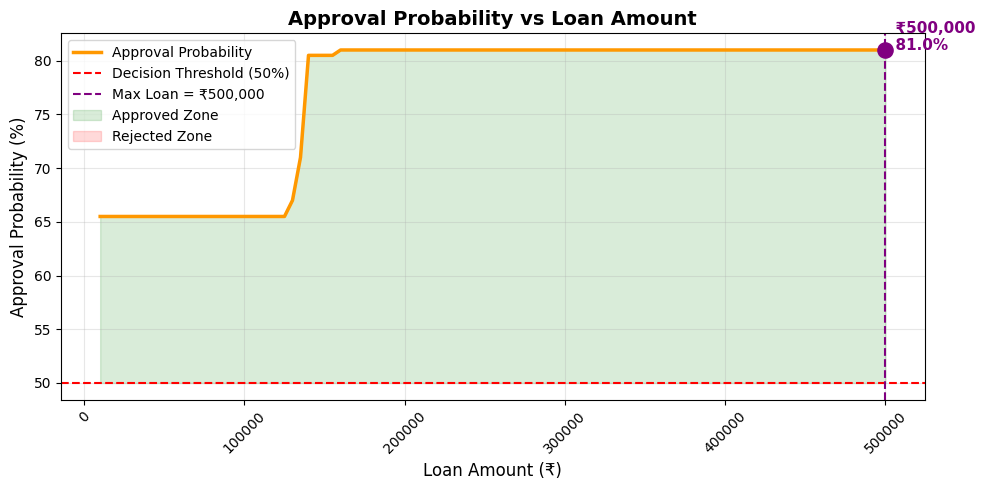

In [ ]:

print("Enter your details (Loan Amount will be tested automatically)\n")

loan_salary     = float(input("💰 Annual Salary          (e.g. 60000)  : "))
loan_age        = float(input("🎂 Age                    (e.g. 30)     : "))
loan_cscore     = float(input("📊 Credit Score  (300-850, e.g. 700)    : "))
loan_emp_status = int(input  ("💼 Employment    (1=Employed, 0=Not)    : "))

# Test loan amounts from 10000 to 500000
loan_amounts  = list(range(10000, 500001, 5000))
loan_probs    = []

for amt in loan_amounts:
    temp_df = pd.DataFrame([{
        'Salary'          : loan_salary,
        'Age'             : loan_age,
        'CreditScore'     : loan_cscore,
        'EmploymentStatus': loan_emp_status,
        'LoanAmount'      : amt
    }])
    rf_p  = rf.predict_proba(temp_df)[0][1]
    ann_p = float(ann.predict(scaler.transform(temp_df), verbose=0)[0][0])
    loan_probs.append((RF_WEIGHT * rf_p) + (ANN_WEIGHT * ann_p))

# Find maximum loan amount still above 50%
max_loan      = None
max_loan_prob = None
for amt, prob in zip(loan_amounts, loan_probs):
    if prob >= 0.5:
        max_loan      = amt
        max_loan_prob = prob

print("\n" + "=" * 55)
print("   MAXIMUM LOAN AMOUNT ANALYSIS")
print("=" * 55)
if max_loan:
    print(f"  ✅ Maximum Loan you can get      : ₹ {max_loan:,}")
    print(f"  📊 Approval Probability          : {max_loan_prob*100:.1f}%")
else:
    print("  ❌ Loan not approved at any amount.")
    print("     Try improving salary or credit score first.")
print("=" * 55)

# ── Plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(loan_amounts, [p * 100 for p in loan_probs],
         color='#FF9800', linewidth=2.5, label='Approval Probability')
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='Decision Threshold (50%)')

if max_loan:
    plt.axvline(max_loan, color='purple', linestyle='--', linewidth=1.5,
                label=f'Max Loan = ₹{max_loan:,}')
    plt.scatter([max_loan], [max_loan_prob * 100], color='purple', s=120, zorder=5)
    plt.annotate(f'  ₹{max_loan:,}\n  {max_loan_prob*100:.1f}%',
                 xy=(max_loan, max_loan_prob * 100),
                 fontsize=11, color='purple', fontweight='bold')

plt.fill_between(loan_amounts, [p * 100 for p in loan_probs],
                 50, where=[p >= 0.5 for p in loan_probs],
                 alpha=0.15, color='green', label='Approved Zone')
plt.fill_between(loan_amounts, [p * 100 for p in loan_probs],
                 50, where=[p < 0.5 for p in loan_probs],
                 alpha=0.15, color='red', label='Rejected Zone')

plt.title('Approval Probability vs Loan Amount', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount (₹)', fontsize=12)
plt.ylabel('Approval Probability (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()